<a href="https://colab.research.google.com/github/chenjinm/chenjinm.github.io/blob/main/LSTM_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import all the required libraries

---



In [1]:
import pandas as pd
import datetime as dt
from datetime import date
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
import tensorflow as tf

# Define start day to fetch the dataset from the yahoo finance library

---



In [2]:


START = "2015-01-01"
TODAY = date.today().strftime("%Y-%m-%d")

# Define a function to load the dataset

def load_data(ticker):
    data = yf.download(ticker, START, TODAY)
    data.reset_index(inplace=True)
    return data

In [11]:
data = load_data('AAPL')
df=data
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2015-01-02,24.320433,24.789802,23.879981,24.778679,212818400
1,2015-01-05,23.635284,24.169164,23.448427,24.089082,257142000
2,2015-01-06,23.637512,23.897778,23.274918,23.699798,263188400
3,2015-01-07,23.968960,24.069062,23.735387,23.846612,160423600
4,2015-01-08,24.889902,24.947740,24.180287,24.298187,237458000


In [12]:
df = df.drop(['Date'], axis = 1)
df.head()

<ipython-input-12-e54f1e21f52c>:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(['Date'], axis = 1)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
0,24.320433,24.789802,23.879981,24.778679,212818400
1,23.635284,24.169164,23.448427,24.089082,257142000
2,23.637512,23.897778,23.274918,23.699798,263188400
3,23.968960,24.069062,23.735387,23.846612,160423600
4,24.889902,24.947740,24.180287,24.298187,237458000


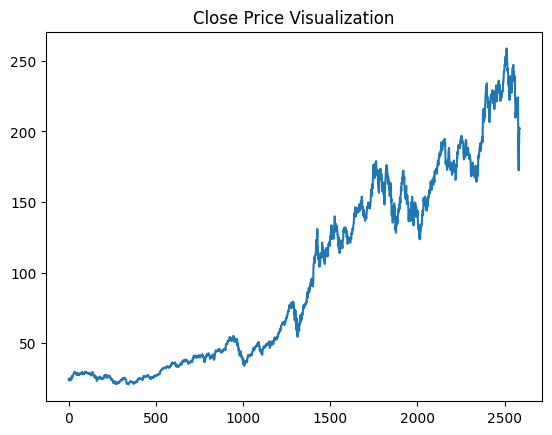

In [13]:
plt.title("Close Price Visualization")
plt.plot(df.Close)

In [14]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
0,24.320433,24.789802,23.879981,24.778679,212818400
1,23.635284,24.169164,23.448427,24.089082,257142000
2,23.637512,23.897778,23.274918,23.699798,263188400
3,23.968960,24.069062,23.735387,23.846612,160423600
4,24.889902,24.947740,24.180287,24.298187,237458000
...,...,...,...,...,...
2582,198.850006,200.610001,171.889999,171.949997,184395900
2583,190.419998,194.779999,183.000000,189.070007,121880000
2584,198.149994,199.539993,186.059998,186.100006,87435900


# Plotting moving averages of 100 day

---



In [15]:
ma100 = df.Close.rolling(100).mean()
ma100

Ticker,AAPL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2582,232.744357
2583,232.399829
2584,232.101635
2585,231.879307


Text(0.5, 1.0, 'Graph Of Moving Averages Of 100 Days')

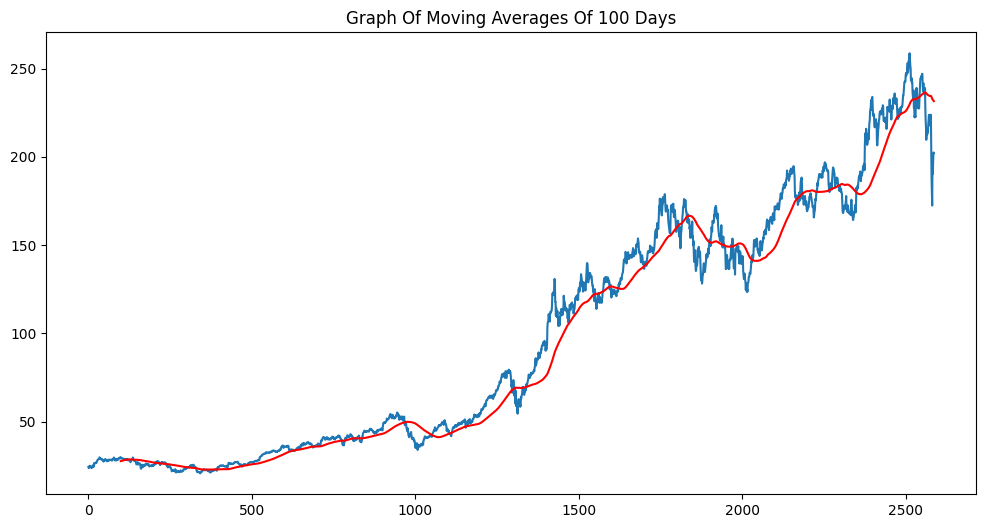

In [16]:
plt.figure(figsize = (12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.title('Graph Of Moving Averages Of 100 Days')

# Defining 200 days moving averages and plotting comparision graph with 100 days moving averages

---



In [17]:
ma200 = df.Close.rolling(200).mean()
ma200

Ticker,AAPL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2582,228.250512
2583,228.165398
2584,228.114299
2585,228.064221


Text(0.5, 1.0, 'Comparision Of 100 Days And 200 Days Moving Averages')

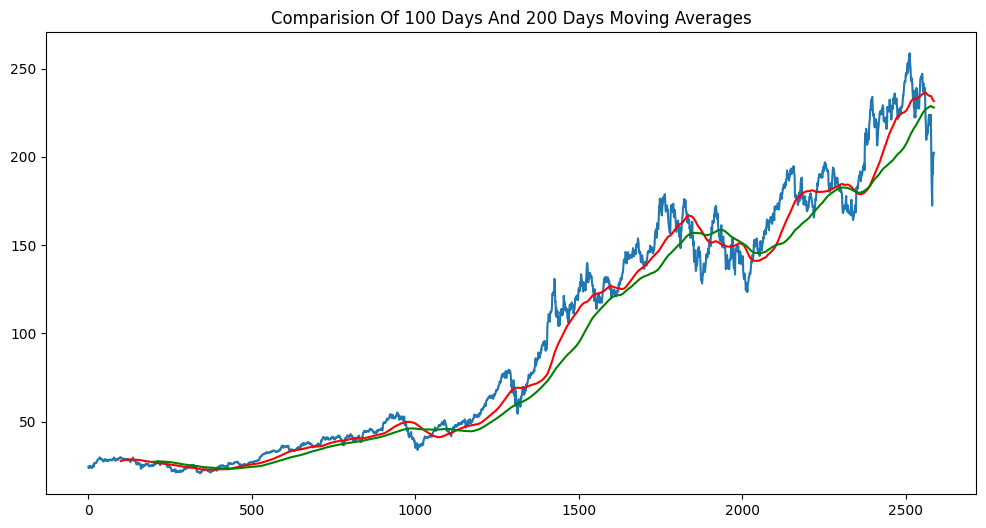

In [18]:
plt.figure(figsize = (12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.plot(ma200, 'g')
plt.title('Comparision Of 100 Days And 200 Days Moving Averages')

In [ ]:
df.shape

(2090, 5)

# Spliting the dataset into training (70%) and testing (30%) set

In [19]:
# Splitting data into training and testing

train = pd.DataFrame(data[0:int(len(data)*0.70)])
test = pd.DataFrame(data[int(len(data)*0.70): int(len(data))])

print(train.shape)
print(test.shape)

(1810, 6)
(777, 6)


In [20]:
train.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2015-01-02,24.320433,24.789802,23.879981,24.778679,212818400
1,2015-01-05,23.635284,24.169164,23.448427,24.089082,257142000
2,2015-01-06,23.637512,23.897778,23.274918,23.699798,263188400
3,2015-01-07,23.968960,24.069062,23.735387,23.846612,160423600
4,2015-01-08,24.889902,24.947740,24.180287,24.298187,237458000


In [21]:
test.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
1810,2022-03-11,152.262817,156.740270,152.036489,156.395845,96970100
1811,2022-03-14,148.218307,151.662499,147.706610,149.035075,108732100
1812,2022-03-15,152.617050,153.089407,147.982161,148.493858,92964300
1813,2022-03-16,157.045303,157.448769,151.997112,154.545811,102300200
1814,2022-03-17,158.058868,158.432814,155.116554,156.080924,75615400


# Using MinMax scaler for normalization of the dataset

---



In [22]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [23]:
train_close = train.iloc[:, 4:5].values
test_close = test.iloc[:, 4:5].values

In [24]:
data_training_array = scaler.fit_transform(train_close)
data_training_array

array([[0.02631938],
       [0.02197936],
       [0.01952937],
       ...,
       [0.85397883],
       [0.87045287],
       [0.86252545]])

In [51]:
test_training_array = scaler.fit_transform(test_close)
test_training_array

array([[0.2387355 ],
       [0.18353443],
       [0.17947565],
       [0.22486143],
       [0.2363738 ],
       [0.25039569],
       [0.2725347 ],
       [0.28729423],
       [0.30559635],
       [0.32825195],
       [0.34906324],
       [0.33644361],
       [0.36980038],
       [0.38352672],
       [0.37828713],
       [0.35017012],
       [0.35415524],
       [0.37577794],
       [0.33784583],
       [0.32899033],
       [0.33356551],
       [0.31090973],
       [0.30581788],
       [0.30116827],
       [0.32500494],
       [0.27556056],
       [0.28367845],
       [0.31127858],
       [0.31238591],
       [0.2943052 ],
       [0.25489697],
       [0.26323633],
       [0.2164485 ],
       [0.24109684],
       [0.26021062],
       [0.22235252],
       [0.23297924],
       [0.24419645],
       [0.27504411],
       [0.21887777],
       [0.21089632],
       [0.21525665],
       [0.20032752],
       [0.12102604],
       [0.13447721],
       [0.14157205],
       [0.16603532],
       [0.151

In [53]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

x_test = []
y_test = []

for i in range(100, test_training_array.shape[0]):
    x_test.append(test_training_array[i-100: i])
    y_test.append(test_training_array[i, 0])

x_test, y_test = np.array(x_test), np.array(y_test)


In [54]:
x_test.shape

(677, 100, 1)

In [46]:
x_train.shape


(1710, 100, 1)

# ML Model (LSTM)

---



In [55]:
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.models import Sequential

In [56]:
model = Sequential()
model.add(LSTM(units = 50, activation = 'relu', return_sequences=True
              ,input_shape = (x_train.shape[1], 1)))
model.add(Dropout(0.2))


model.add(LSTM(units = 60, activation = 'relu', return_sequences=True))
model.add(Dropout(0.3))


model.add(LSTM(units = 80, activation = 'relu', return_sequences=True))
model.add(Dropout(0.4))


model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units = 1))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [57]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

# Training the model

---



In [58]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics = ['MAE'])
model.fit(x_train, y_train, validation_data = (x_test, y_test) ,epochs = 50)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 56s 178ms/step - MAE: 0.1670 - loss: 0.0629 - val_MAE: 0.1015 - val_loss: 0.0154
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - MAE: 0.0536 - loss: 0.0071 - val_MAE: 0.0752 - val_loss: 0.0086
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - MAE: 0.0445 - loss: 0.0053 - val_MAE: 0.0689 - val_loss: 0.0070
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - MAE: 0.0463 - loss: 0.0058 - val_MAE: 0.0671 - val_loss: 0.0067
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - MAE: 0.0410 - loss: 0.0046 - val_MAE: 0.0652 - val_loss: 0.0064
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - MAE: 0.0398 - loss: 0.0042 - val_MAE: 0.0666 - val_loss: 0.0066
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - MAE: 0.0487 - loss: 0.0059 - val_MAE: 0.0643 - val_loss: 0.0062
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - MAE: 0.0489 - loss: 0.0065 - val_MAE: 0.0610 - val_loss: 0.0057
Epoch 9/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - MAE: 0.04

In [59]:
model.save('keras_model.h5')

In [60]:

test_close.shape
test_close

array([[156.39584515],
       [149.03507466],
       [148.4938583 ],
       [154.54581074],
       [156.08092378],
       [157.950669  ],
       [160.90278835],
       [162.87089426],
       [165.31138391],
       [168.33238892],
       [171.10746429],
       [169.42470275],
       [173.87265188],
       [175.70298634],
       [175.00431394],
       [171.25505972],
       [171.78645453],
       [174.6697271 ],
       [169.6116815 ],
       [168.43084825],
       [169.04092358],
       [166.01989505],
       [165.34092422],
       [164.72092299],
       [167.89941733],
       [161.30627041],
       [162.38874866],
       [166.06907917],
       [166.21673611],
       [163.80576949],
       [158.550891  ],
       [159.66290066],
       [153.42399128],
       [156.71071626],
       [159.25943807],
       [154.21126124],
       [155.62827792],
       [157.12403328],
       [161.23740483],
       [153.74792192],
       [152.68363772],
       [153.26506437],
       [151.2743435 ],
       [140

In [61]:
past_100_days = pd.DataFrame(train_close[-100:])

In [62]:
test_df = pd.DataFrame(test_close)

**Defining the final dataset for testing by including last 100 coloums of the training dataset to get the prediction from the 1st column of the testing dataset.**

---


In [65]:
final_df = past_100_days._append(test_df, ignore_index = True)

In [66]:
final_df.head()

,0
0,140.777600
1,144.271295
2,145.929805
3,146.037720
4,146.901369


In [67]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.12160865],
       [0.14780912],
       [0.16024689],
       [0.16105619],
       [0.167533  ],
       [0.16009956],
       [0.16488331],
       [0.165104  ],
       [0.16848969],
       [0.14935433],
       [0.162381  ],
       [0.15995232],
       [0.17268457],
       [0.18144244],
       [0.1853557 ],
       [0.18181763],
       [0.1728993 ],
       [0.17157277],
       [0.16376037],
       [0.15985388],
       [0.17415249],
       [0.17098328],
       [0.17879558],
       [0.19876977],
       [0.22780863],
       [0.25751149],
       [0.25338415],
       [0.25065729],
       [0.24195997],
       [0.24048589],
       [0.2450556 ],
       [0.30025995],
       [0.23584264],
       [0.27475831],
       [0.27674825],
       [0.31205277],
       [0.3345322 ],
       [0.35502176],
       [0.35723304],
       [0.40079194],
       [0.35752776],
       [0.35649607],
       [0.38723031],
       [0.3183173 ],
       [0.30615636],
       [0.33033108],
       [0.34123908],
       [0.361

In [68]:
input_data.shape

(877, 1)

# Testing the model

---



In [69]:
x_test = []
y_test = []
for i in range(100, input_data.shape[0]):
   x_test.append(input_data[i-100: i])
   y_test.append(input_data[i, 0])

In [ ]:
x_test, y_test = np.array(x_test), np.array(y_test)
print(x_test.shape)
print(y_test.shape)

(627, 100, 1)
(627,)


# Making prediction and plotting the graph of predicted vs actual values

---



In [85]:
# Making predictions

y_pred = model.predict(x_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 241ms/step


In [86]:
y_pred.shape

(100, 1)

In [87]:
y_test

[np.float64(0.23873550426831525),
 np.float64(0.1835344305439548),
 np.float64(0.17947565373985963),
 np.float64(0.2248614287116102),
 np.float64(0.2363737952735223),
 np.float64(0.2503956893228536),
 np.float64(0.2725346974726288),
 np.float64(0.2872942338111031),
 np.float64(0.30559634630995247),
 np.float64(0.3282519528553687),
 np.float64(0.34906324435573177),
 np.float64(0.3364436083575937),
 np.float64(0.36980038381261804),
 np.float64(0.3835267223302987),
 np.float64(0.3782871258883447),
 np.float64(0.3501701157472825),
 np.float64(0.35415523714465125),
 np.float64(0.37577793844050933),
 np.float64(0.33784582947585706),
 np.float64(0.328990334921609),
 np.float64(0.3335655099313779),
 np.float64(0.31090972696916297),
 np.float64(0.30581787969813035),
 np.float64(0.3011682667925264),
 np.float64(0.32500494266939617),
 np.float64(0.27556055504958454),
 np.float64(0.28367845004200287),
 np.float64(0.3112785764487027),
 np.float64(0.3123859090712737),
 np.float64(0.2943052005097375)

In [88]:
y_pred

array([[0.21804425],
       [0.21823645],
       [0.21833245],
       [0.21833873],
       [0.21838966],
       [0.21833132],
       [0.2183685 ],
       [0.21837024],
       [0.21839745],
       [0.2182481 ],
       [0.21834898],
       [0.21833017],
       [0.21843272],
       [0.21850944],
       [0.21854523],
       [0.21851286],
       [0.21843454],
       [0.21842328],
       [0.21835965],
       [0.21832941],
       [0.21844518],
       [0.21841827],
       [0.21848574],
       [0.21861513],
       [0.21869458],
       [0.21881273],
       [0.2187951 ],
       [0.2187833 ],
       [0.21874537],
       [0.2187391 ],
       [0.2187589 ],
       [0.2189063 ],
       [0.21872106],
       [0.21885201],
       [0.21885599],
       [0.21892963],
       [0.21896988],
       [0.2190093 ],
       [0.2190136 ],
       [0.2190969 ],
       [0.21901418],
       [0.21901217],
       [0.2190719 ],
       [0.21893957],
       [0.21891898],
       [0.21896143],
       [0.21898231],
       [0.219

In [89]:
scaler.scale_

array([0.00749936])

In [91]:
scale_factor = 1/0.00985902
y_pred = y_pred * scale_factor
y_test = [v * scale_factor for v in y_test]


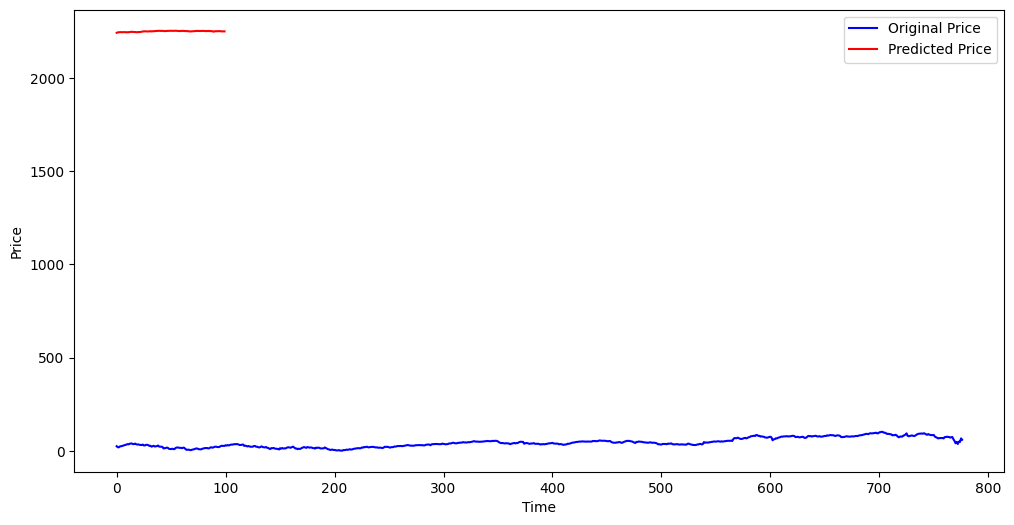

In [93]:
plt.figure(figsize = (12,6))
plt.plot(y_test, 'b', label = "Original Price")
plt.plot(y_pred, 'r', label = "Predicted Price")
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

# Model evaluation

In [94]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print("Mean absolute error on test set: ", mae)

ValueError: Found input variables with inconsistent numbers of samples: [777, 100]